# ML Regression

In [ ]:
!pip install contextily
!pip install ydata-profiling
!pip install fg-data-profiling

In [ ]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
import requests
from io import StringIO
from ydata_profiling import ProfileReport
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
# Defining the downloaded data set
# SOURCE: https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data
#file = "/home/gnirut/Descargas/AB_NYC_2019.csv"
url = "https://raw.githubusercontent.com/LopezX2Daniel/Development_Team_Project_Project_Report/refs/heads/master/AB_NYC_2019.csv"

file = requests.get(url)
df = pd.read_csv(StringIO(file.text))

In [ ]:
# REFERENCE: https://towardsdatascience.com/a-data-scientists-essential-guide-to-exploratory-data-analysis-25637eee0cf6/
# REFERENCE: https://medium.com/ydata-ai/auditing-data-quality-with-pandas-profiling-b1bf1919f856
# We will start with data_profiling, is a library very useful in creating and automated report for Data Profiling

profile = ProfileReport(df, title="Airbnb DataSet")

# Save the report to .html
profile.to_file("airbnb_dataset.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:02<00:00,  6.23it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# General overview
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
# Now, lets see the lenght of the data set
df.shape
# 16 columns by 48K data

(48895, 16)

In [ ]:
# Lets discard if we have duplicated rows
df[df.duplicated()].count()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# Aside of duplicated values, lets confirm we dont have missing values:
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# Some Data cleaning
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['last_review'] = df['last_review'].fillna('Unknown')

In [ ]:
# Now, we will calculate general statistical values for each columns:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
# And for String values:
df.describe(include="object")

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48879,48874,48895,48895,48895,48895
unique,47905,11452,5,221,3,1765
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,Unknown
freq,18,417,21661,3920,25409,10052


In [ ]:
# value_counts is useful for having an overview of String columns
df["neighbourhood"].value_counts()

,count
neighbourhood,
Williamsburg,3920
Bedford-Stuyvesant,3714
Harlem,2658
Bushwick,2465
Upper West Side,1971
...,...
Richmondtown,1
Fort Wadsworth,1
New Dorp,1


In [ ]:
df["id"] = df.index

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df['price'] >= lower) &
        (df['price'] <= upper)]

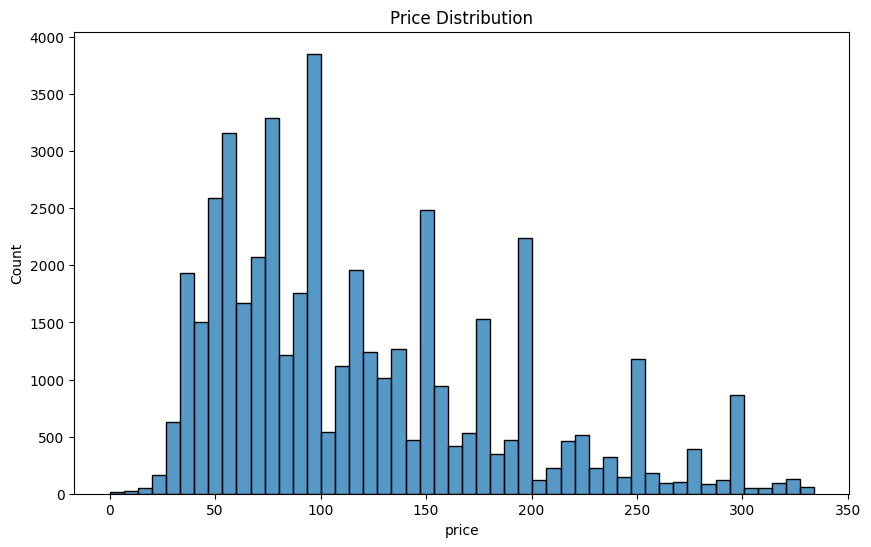

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df['price'], bins=50)

plt.title("Price Distribution")
plt.show()



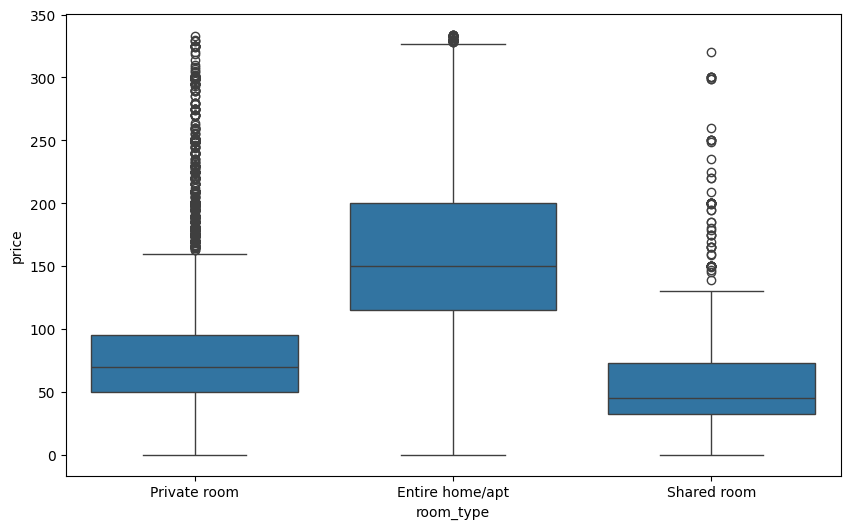

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='room_type',
    y='price',
    data=df)
plt.show()

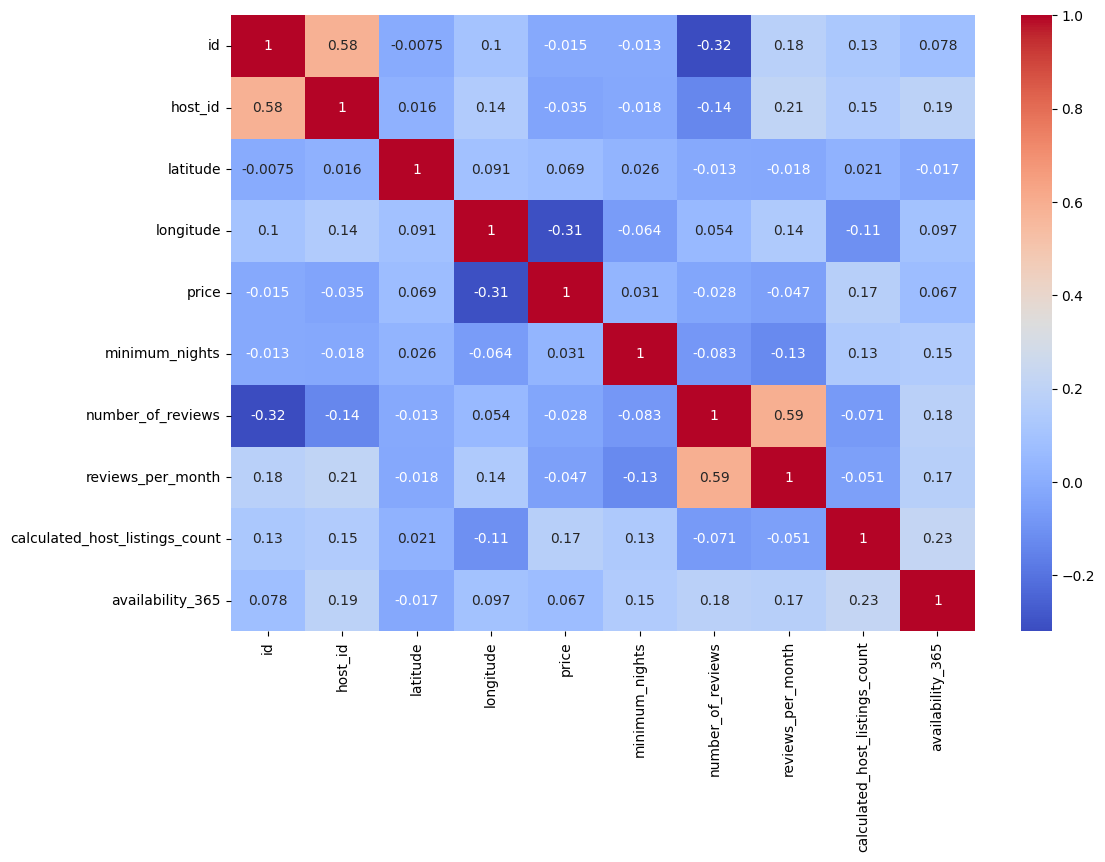

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

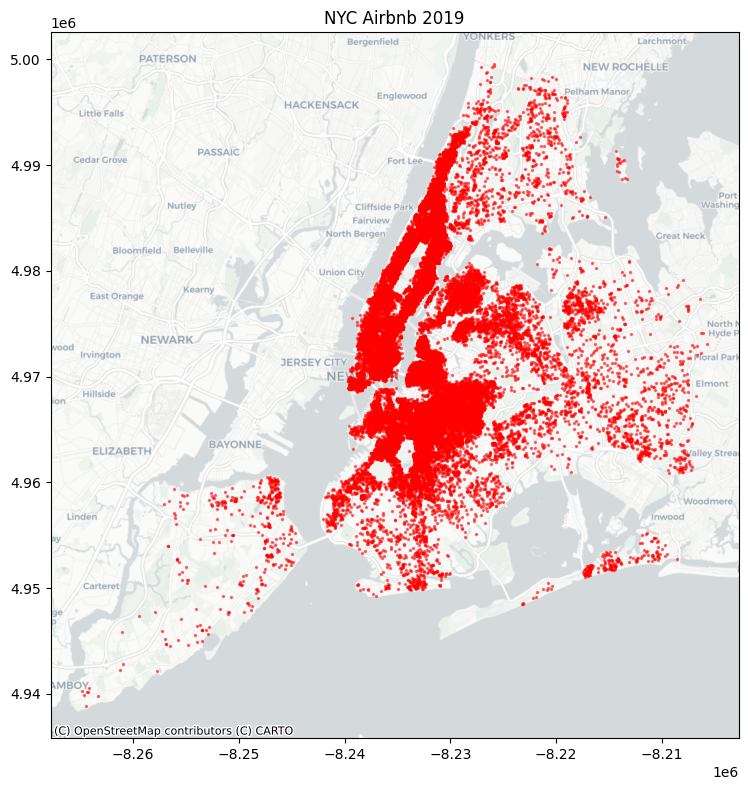

In [ ]:
# Reference: https://towardsdatascience.com/geopandas-a-practical-guide-c1e15d4d58d5
gfd = geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(df["longitude"], df["latitude"]), crs=4326)
fig, ax = plt.subplots(figsize=(10, 8))
mapa_wm = gfd.to_crs(epsg=3857)
mapa_wm.plot(ax=ax, markersize=2, color='red', alpha=0.5)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title('NYC Airbnb 2019')
plt.tight_layout()
plt.show()

The above code takes all the coordinates of the data set to plot the below graphic. <br>
The highest density is in Manhattan and Brooklyn.<br>
Queens appears more dispersed to the east. <br>
The Bronx has very little presence, and Staten Island is almost nonexistent.

In [ ]:
df["english_words"] = df["name"].str.contains(r"[a-zA-Z]", regex=True)
df = df.loc[df["english_words"] == True]
df["word length"] = df["name"].str.len()
df = df[(df["price"] > 0) & (df["number_of_reviews"] > 0)]
df["quasi_revenue"] = df["price"] * df["number_of_reviews"]

counting = {}

for index, values in df.iterrows():
    temp = values["name"].strip()
    temp = temp.lower()
    temp = temp.replace("-", " ")
    temp = temp.replace("!", "")
    temp = temp.replace("/", "")
    temp = temp.split(" ")
    for word in temp:
        if word in list(counting.keys()):
            counting[word] = counting[word] + 1
        else:
            counting[word] = 1

counting.pop("&")
counting.pop("the")
counting.pop("by")
counting.pop("in")
counting.pop("to")
counting.pop("on")
counting.pop("1")
counting.pop("+")
counting.pop("2")
counting.pop("of")
counting.pop("")
counting.pop("with")
counting.pop("and")
counting.pop("a")
counting.pop("w")
counting.pop("|")
counting.pop("3")
counting.pop("4")
counting.pop("5")
counting.pop("at")
counting.pop("15")
counting.pop("20")
counting.pop("l")
counting.pop("30")
counting.pop("6")
counting.pop("@")
counting.pop("or")
counting.pop(",")
counting.pop("25")
counting.pop("7")
counting.pop("#2")
counting.pop("❤️")
counting.pop("~")
counting.pop("☆")

desc = {k: v for k, v in sorted(counting.items(), key=lambda item: item[1],  reverse=True)}

# Totals: 48761
# Greater than zero: 38746
# Almost 20% usless data

unique_words = desc.keys()
# Which words in names are associated with more revenue?
df["word_list"] = df["name"].str.split(" ")
df["word_count"] = df["word_list"].str.len()
df["value_per_word"] = df["quasi_revenue"] / df["word_count"]

word_values = {}
word_list = list(df["word_list"])
value_per_word = list(df["value_per_word"])

for word in unique_words:
    for id_ in range(len(word_list)):
        if word in word_list[id_]:
            if word in word_values:
                word_values[word] = round(word_values[word] + value_per_word[id_],2)
            else:
                word_values[word] = round(value_per_word[id_], 2)

word_values_sorted = {k: v for k, v in sorted(word_values.items(), key=lambda item: item[1], reverse=True)}

limit = 0
for key, value in word_values_sorted.items():
    print(key, ":", value)
    limit =+1
    if limit > 100:
        break

/tmp/ipykernel_727/2094028152.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["english_words"] = df["name"].str.contains(r"[a-zA-Z]", regex=True)


room : 990377.79
bedroom : 910163.04
apartment : 886468.33
private : 603339.2
near : 557515.27
from : 520426.05
apt : 481054.04
studio : 394195.28
for : 305361.82
heart : 301763.39
min : 256457.19
cozy : 237682.81
home : 203979.27
close : 203660.48
brownstone : 173327.49
loft : 164618.62
garden : 151800.81
spacious : 150323.43
location : 149697.65
bed : 144239.65
renovated : 128692.94
floor : 124806.36
mins : 121267.83
quiet : 119701.54
sunny : 112503.57
house : 111033.8
beautiful : 110448.68
train : 108614.09
bath : 105964.35
away : 103727.41
one : 103281.54
bathroom : 103273.88
duplex : 97645.63
minutes : 96619.26
subway : 94341.6
large : 93846.74
modern : 87063.78
townhouse : 86469.11
block : 83471.49
space : 79586.17
10 : 79266.14
clean : 77503.37
new : 76272.42
great : 76097.24
bright : 69142.18
apt. : 67350.55
bedrooms : 66473.42
place : 65616.23
two : 64427.42
bdrm : 64265.76
view : 62007.37
park : 61688.2
charming : 59745.95
suite : 59537.0
2nd : 58868.99
next : 58711.68
prime 

In the section above, we use the description of each Airbnb listing to break down the text word by word, removing overly generic terms and determining the best keywords to use in the description that are associated with higher revenue. <br>
In this case, "revenue" is calculated as price multiplied by the number of visits, due to the lack of a true revenue metric.

In [ ]:
# importing again the dataset
df = pd.read_csv(StringIO(file.text))
df.index = df["id"]
df = df.drop(columns=["id"])

In [ ]:
# RANDOM FOREST
# REFERENCE: https://towardsdatascience.com/random-forest-explained-a-visual-guide-with-code-examples-9f736a6e1b3c
#from cuml.ensemble import RandomForestRegressor #For NVIDIA GPU
# RandomForestRegressor is to predict numbers
# RandomForestClassifier is to predict yes/no values

# Some data cleaning:
df['reviews_per_month'] = df['reviews_per_month'].fillna(df['reviews_per_month'].median())
# 0 quartile = 0 quantile = 0 percentile
# 1 quartile = 0.25 quantile = 25 percentile
# 2 quartile = 0.5 quantile = 50 percentile (median)
# 3 quartile = 0.75 quantile = 75 percentile
# 4 quartile = 1.0 quantile = 100 percentile
df = df.loc[(df["price"] > df["price"].quantile(0.05)) & (df["price"] < df["price"].quantile(0.90))]
# df["price"].describe()
# df["price"].hist(bins=50)
# plt.show()
df["price"].describe()

X = pd.get_dummies(df[["latitude", "longitude", "room_type", "number_of_reviews", "calculated_host_listings_count", "availability_365",
                       "minimum_nights", "reviews_per_month"]],
                   columns=["room_type"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In the section above, we use a Random Forest Regressor to predict Airbnb listing prices in NCY based on location, room type, and activity metrics. <br>
Random Forest was chosen over a simple linear regression because the relationship between price and location is inherently non-linear.

Before training, two cleaning decisions were applied to the data: Missing values in reviews_per_month were filled with the median rather than dropping rows,
preserving listings that simply had no reviews yet. Pricing outliers were removed by keeping only listings between the 5th and 90th percentile,
eliminating both suspiciously cheap listings and luxury outliers that would otherwise dominate the error metric.

The features used to predict price are latitude, longitude, room type, number of reviews, host listing count, availability, minimum nights, and reviews per month.
Room type is the only categorical variable and is one-hot encoded into binary columns since the model requires numeric input.
The dataset is then split 80/20 into training and test sets.

In [ ]:
rfr = RandomForestRegressor(n_estimators=1000, max_features="sqrt", random_state=42, min_samples_leaf=1, n_jobs=-1)
rfr.fit(X_train, y_train)

y_pred_rfr = rfr.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred_rfr)
print(rmse)

37.0175992390248


The model is configured with 10,000 decision trees (1000 colab version), where each tree is built on a random bootstrap sample of the training data and considers only the square root of available features at each split point.

Once trained, the model predicts prices for the held-out test set and evaluates performance using Root Mean Squared Error. An RMSE of +-37 USD against a mean listing price of +-117 USD represents a relative error of roughly 31%, which is reasonable given that the dataset lacks features that typically drive premium pricing such as property amenities, photos, or host reputation scores.

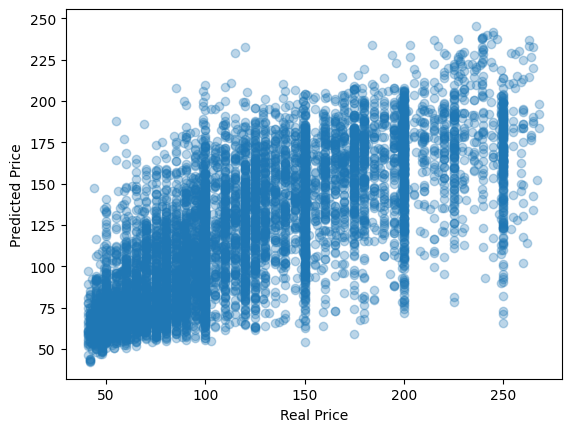

In [ ]:
plt.scatter(y_test, y_pred_rfr, alpha=0.3)
plt.xlabel("Real Price")
plt.ylabel("Predicted Price")
plt.show()

The scatter plot compares actual prices against model predictions, where a perfect model would show all points along a diagonal line from bottom-left to top-right.

The plot reveals two characteristic limitations of Random Forest on this dataset. <br>
First: The model has a prediction ceiling around 180 USD. This happens because Random Forest predicts by averaging tree outputs, and with few training examples at high price points the average gets pulled toward the center of the distribution. <br>

Second, the vertical bands of points indicate that for many different actual prices the model returns the same predicted value, which reflects the discrete nature of how decision trees make splits.

Overall the spread is reasonable in the 50-150 USD range where most listings concentrate, but the model systematically underestimates luxury listings, which is consistent with the 37 USD RMSE being driven largely by those high-price prediction errors.

In [ ]:
#import cudf
#import cupy as cp

# REFERENCE https://medium.com/zackary-yen/accelerating-xgboost-with-gpu-a-step-by-step-guide-3660cc3bb840
# REFENRECE https://towardsdatascience.com/need-for-speed-cudf-pandas-vs-pandas-16b87009aefa
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=6, early_stopping_rounds=50) # Only for NVIDIA GPU: device="cuda",
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)],  verbose=100)

[0]	validation_0-rmse:56.43761
[100]	validation_0-rmse:41.44698
[200]	validation_0-rmse:38.44571
[300]	validation_0-rmse:37.75742
[400]	validation_0-rmse:37.50500
[500]	validation_0-rmse:37.39344
[600]	validation_0-rmse:37.31217
[700]	validation_0-rmse:37.25503
[800]	validation_0-rmse:37.21577
[900]	validation_0-rmse:37.18213
[999]	validation_0-rmse:37.15772


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

As an alternative to Random Forest, we evaluate XGBoost, a model that takes a fundamentally different approach. <br>
While Random Forest builds all trees independently and averages their predictions, XGBoost builds trees sequentially where each tree specifically targets the residual error left by the previous one.

Rather than fixing an arbitrary number of trees, early stopping monitors the RMSE on the test set after each tree and halts training automatically if 50 consecutive trees fail to improve the score. This prevents overfitting. <br>

Both models ultimately extract the same predictive signal available in the dataset, suggesting that further improvement would require additional features rather than algorithmic changes.

In [ ]:
importances = pd.Series(rfr.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False).head(10))

longitude                         0.200611
room_type_Entire home/apt         0.200531
latitude                          0.161659
room_type_Private room            0.145420
availability_365                  0.071341
reviews_per_month                 0.069475
number_of_reviews                 0.057336
minimum_nights                    0.049501
calculated_host_listings_count    0.038299
room_type_Shared room             0.005828
dtype: float64


In [ ]:
y_pred_xgbr = xgb.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred_xgbr)
print(rmse)

37.156982421875


Both models are evaluated on the same held-out test set and converge to a RMSE of approximately 37 USD, confirming that the performance ceiling is determined by the available features rather than the choice of algorithm. <br>

XGBoost with early stopping achieved this in 1,431 trees out of a configured 50,000 (1,000 for the Colab version), while Random Forest required all 10,000 trees to reach an equivalent result.

In [ ]:
# Estimation for Random Forest
new = pd.DataFrame([{
    "latitude": 40.75362,
    "longitude": -73.98377,
    "room_type_Entire home/apt": 1,
    "room_type_Private room": 0,
    "room_type_Shared room": 0,
    "number_of_reviews": 45,
    "calculated_host_listings_count": 2,
    "availability_365": 355,
    "minimum_nights": 1,
    "reviews_per_month": 0.38
}])

new = new[X_train.columns]

estimated_price = rfr.predict(new)
print("Random Forest prediction:", estimated_price[0])

Random Forest prediction: 186.36


In [ ]:
new_gpu = new

estimated_price = xgb.predict(new_gpu)
print("XGBoost prediction:", estimated_price[0])

XGBoost prediction: 190.39421


### Final Thoughts

Both models receive the exact same characteristics: Random Forest predicts 186 and XGBoost 188. <br>

The 2 USD difference between the two is consistent with what we observed during training.<br>
Random Forest tends to underestimate because it averages the predictions of all the trees, pulling the result toward the dataset mean.<br>
XGBoost, on the other hand, by iteratively correcting the residuals, better captures the premium of an entire apartment in Midtown and produces a higher estimate.

With a similar RMSE of 37 for both, the 2 USD difference between predictions is within the margin of error of both models, so neither is definitively correct.

# ML Clustering

In [ ]:
url = "https://raw.githubusercontent.com/LopezX2Daniel/Development_Team_Project_Project_Report/refs/heads/master/AB_NYC_2019.csv"

file = requests.get(url)
df = pd.read_csv(StringIO(file.text))

In [ ]:
df.drop(['id',
         'name',
         'host_name',
         'last_review'],
        axis=1,
        inplace=True)

le = LabelEncoder()

categorical_cols = [
    'neighbourhood_group',
    'neighbourhood',
    'room_type'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

cluster_data = df[[
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365']]

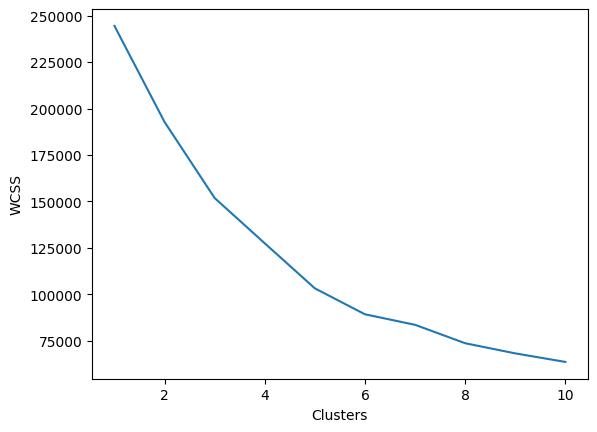

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_data
)

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)

plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(
    scaled_data
)

df['Cluster'] = clusters

score = silhouette_score(
    scaled_data,
    clusters
)

print("Silhouette Score:",score)

Silhouette Score: 0.44532023867892234


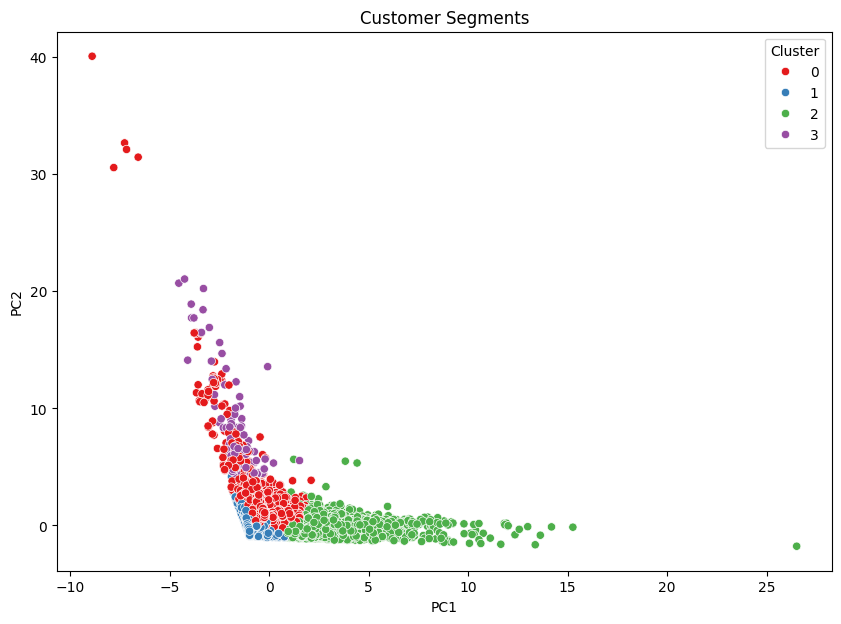

In [ ]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled_data
)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = clusters

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segments")

plt.show()

cluster_profile = df.groupby(
    'Cluster'
).mean()

In [ ]:
cluster_profile

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
Cluster,,,,,,,,,,,,
0,8.977632e+07,1.755425,106.201720,40.729403,-73.950808,0.503720,175.206913,14.433509,13.366088,0.762457,20.947071,288.846637
1,5.601873e+07,1.631098,109.140781,40.729020,-73.954999,0.503975,135.194782,4.764560,8.536579,0.513813,2.198144,22.515426
2,7.382731e+07,1.704452,100.624283,40.727762,-73.943169,0.510107,126.244469,2.556405,98.506556,3.933345,2.169489,153.320951
3,6.691498e+07,1.824561,123.271930,40.735972,-73.975632,0.175439,3697.885965,23.771930,4.403509,0.258158,3.078947,189.666667
